In [ ]:
# %reload_ext autoreload
# %autoreload 2

from tqdm import trange
from flygym.compose import ActuatorType
from miniproject.simulation import MiniprojectSimulation
from submission.controller import Controller
import matplotlib.pyplot as plt
import numpy as np
#Seed 1 ok :)
#Seed 67 ok :) with last comit workin seed 1

#Prmts:
#Width threshold for obstacle detection 
#Vision threshold to only keep center vision 



# exam seed 1, 67, 777
sim = MiniprojectSimulation(level=2, seed=777)
controller = Controller(sim)
banana_xy= np.array(sim.world.banana_xy)
min_dist=np.inf

for step in trange(100000):

    head_pos = controller.get_head_position(sim)
    fly_xy = np.array([head_pos[0],head_pos[1]]) 
    dist = np.linalg.norm(fly_xy - banana_xy)
    
    if dist <= min_dist: 
        
        min_dist = dist 
    
    joint_angles, adhesion = controller.step(sim)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
    sim.step()
    sim.render_as_needed()
    
print(f"min dist", min_dist)   
controller.close()
sim.renderer.show_in_notebook()

  0%|          | 0/100000 [00:00<?, ?it/s]

final dist 14.354395022224834


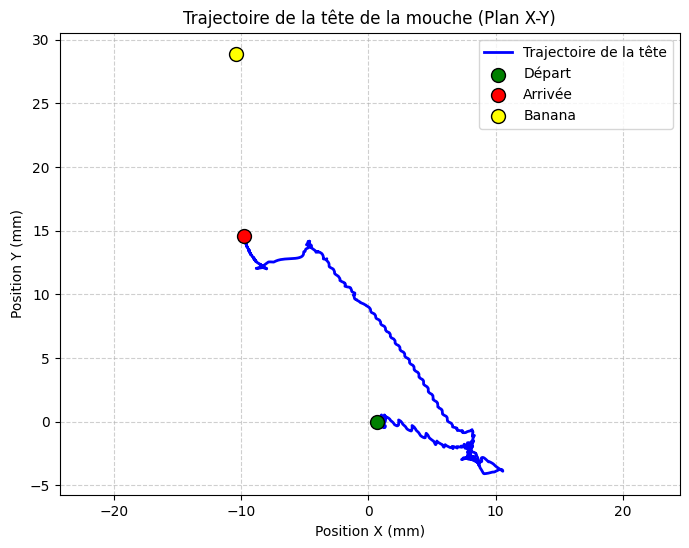

In [2]:
controller.plot_head_trajectory(sim)


In [ ]:
print(sim.world.banana_xy)

In [1]:
import numpy as np
import tqdm
from flygym.compose import ActuatorType
from miniproject import MiniprojectSimulation
from submission.controller import Controller

MAX_NUM_STEPS = 70000
NUM_SEEDS = 10
LEVEL = 2  # change as needed
SUCCESS_RADIUS = 3.0

def run_single_seed(seed):
    sim = MiniprojectSimulation(level=LEVEL, seed=seed, back_cam=False, top_cam=False)
    controller = Controller(sim)

    def get_distance():
        fly_xy = np.array(sim.get_body_positions(sim.fly.name)[0][:2])
        banana_xy = np.array(sim.world.banana_xy)
        #print("banana",banana_xy)
        return np.linalg.norm(fly_xy - banana_xy)

    for step in range(MAX_NUM_STEPS):
        dist = get_distance()
        if dist <= SUCCESS_RADIUS:
            print(f"  seed={seed} → reached banana in {step} steps (dist={dist:.2f})")
            return dist

        joint_angles, adhesion_signals = controller.step(sim)
        sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
        sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion_signals)
        sim.step()

    final_dist = get_distance()
    print(f"  seed={seed} → timed out (final dist={final_dist:.2f})")
    return final_dist


distances = []
seeds = np.random.randint(0, 1000, size=NUM_SEEDS)
#seeds=[1]
for seed in tqdm.tqdm(seeds):
    print(f"Seed {seed}")
    d = run_single_seed(int(seed))
    distances.append(d)
# d=run_single_seed(1)
# distances.append(d)

distances = np.array(distances)
print(f"\n--- Results over {NUM_SEEDS} seeds ---")
print(f"  Mean final distance : {distances.mean():.2f}")
print(f"  Std                 : {distances.std():.2f}")
print(f"  Min / Max           : {distances.min():.2f} / {distances.max():.2f}")
print(f"  Success rate (≤{SUCCESS_RADIUS}mm): {(distances <= SUCCESS_RADIUS).mean()*100:.0f}%")

  0%|          | 0/10 [00:00<?, ?it/s]

Seed 612


OpenCV: FFMPEG: tag 0x39305056/'VP09' is not supported with codec id 167 and format 'webm / WebM'


Fin Stuck Mode au step 47470. Et c'est reparti pour un touuuur
Fin Stuck Mode au step 66794. Et c'est reparti pour un touuuur


 10%|█         | 1/10 [01:56<17:30, 116.67s/it]

...

Fin Stuck Mode au step 69442. Et c'est reparti pour un touuuur


 90%|█████████ | 9/10 [16:45<01:52, 112.85s/it]

  seed=738 → timed out (final dist=11.09)
Seed 288


OpenCV: FFMPEG: tag 0x39305056/'VP09' is not supported with codec id 167 and format 'webm / WebM'
100%|██████████| 10/10 [18:41<00:00, 112.14s/it]

  seed=288 → timed out (final dist=3.38)

--- Results over 10 seeds ---
  Mean final distance : 8.34
  Std                 : 5.35
  Min / Max           : 3.00 / 14.97
  Success rate (≤3.0mm): 40%


In [ ]:
controller.plot_head_trajectory(sim)
